# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

_Fill in your group number **from Brightspace**, names, and student numbers._

|  Group 35  |           Student number          |
|------------|----------------------|
| Belouaer, Zeyd  |        6160662       |,
| Dos Santos Roldão, Vasco  |        6127916       |
| Jacobs, Mats  |        6255698       |
| Kopmels, Kylian  |        6164846       |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time
from Visualizer import Visualizer
import matplotlib.pyplot as plt
"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 2

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 3

<div style="background-color:#f1be3e">

_Write your answer here._

### 1.2 Genetic Algorithm

In [ ]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size):
        self.generations = generations
        self.pop_size = pop_size
    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        pass

#### Question 4

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 5

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 6

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 8

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

In [0]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 20
generations = 20
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

<div style="background-color:#f1be3e">

_Put your code extra blocks above (if any) and write your answer here._

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

Ant Colony Optimization (ACO) is a technique used to solve optimization problems, like the traveling salesman problem. 

#### Question 12

Dead ends forces ants to backtrack, but they do leave pheromones in the dead end, so it causes a suboptimal solution.  
Loops in the maze are also probable causes for bad solutions. If an ant decides to run through a loop, then there will be pheromones in the loop. This will cause other ants to also check out the loop which reinforces a bad path.

#### Question 13

You want to punish long paths, so you divide by the total path length $L_i$.
$$\Delta\tau^k_i = \frac{Q}{L_i}$$
Variables:  
$\Delta\tau^k_i$: amount of pheromone dropped by ant $k$ on link $i$  
$L_i$: the length of the path that ant $k$ took to get back to the nest  
$Q$: a constant that represents how much pheromone is available  

Pheromones act as a kind of memory for the ants, without pheromones the ants would just keep going on random walks, which kind of defeats the purpose of using ACO.

#### Question 14

You want large amounts of pheromone to decay quickly in order to prevent good paths from becoming dominant too quickly. For example, if a path is by far the best one at the start, but the ants find a better one later on, then you want to switch to the better path. If pheromones evaporate very slowly, then old paths will dominate new paths which could prevent a better solution from emerging.  
You also want to evaporate low quantities of pheromones a lot slower, so the colony will always keep paths open. This prevents the colony from giving up on a path, which allows the ants to update the "bad" paths to make sure that it's still bad.

$$
\tau_{i_{t+1}} = (1-\rho) \cdot \tau_{i_t}
$$
Variables:  
$\tau_{i_{t+1}}$: the new amount of pheromones on link $i$ after evaporation  
$\tau_{i_t}$: the amount of pheromones in link $i$ before evaporation  
$\rho$: the evaporation rate, $0$ means no evaporation, $1$ means instant evaporation  

### 2.3 Implementing the Ant Algorithm

In [3]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        self.pheromones = np.where(np.matrix(self.walls).T, 1, 0)

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route: Route, q):
        # Δτ^k_i = Q/L_i
        length = route.size()
        amount_to_add = q / length
        curr_pos = route.get_start()
        for step in route.get_route():
            # update pheromone
            self.pheromones[curr_pos.get_y(), curr_pos.get_x()] += amount_to_add
            # go to next location
            curr_pos = curr_pos.add_direction(step)
        self.pheromones[curr_pos.get_y(), curr_pos.get_x()] += amount_to_add

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes: list[Route], q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        self.pheromones = (1 - rho) * self.pheromones

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/E/S/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position: Coordinate):

        return SurroundingPheromone(
            self.get_pheromone(position.add_direction(Direction.north)),
            self.get_pheromone(position.add_direction(Direction.east)),
            self.get_pheromone(position.add_direction(Direction.south)),
            self.get_pheromone(position.add_direction(Direction.west)),
        )

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        if self.in_bounds(pos):
            return self.pheromones[pos.get_y(),pos.get_x()]
        return np.int64(0)

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])

            # make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])

            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [4]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze: Maze, path_specification: PathSpecification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route1(self):
        route = Route(self.start)
        # go to the next step until you find the end coordinate
        while self.current_position != self.end:
            surroundings = self.maze.get_surrounding_pheromone(self.current_position)
            # take a random direction, but weighted by pheromone quantity
            p = [0,0,0,0]
            for i in range(4):
                p[i] = surroundings.get(Direction(i))

            idx = self.rand.choices([0, 1, 2, 3], weights=p, k=1)[0]
            next_step = Direction(idx)
            route.add(next_step)
            self.current_position = self.current_position.add_direction(next_step)

        return route

In [5]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """
    def __init__(self, maze: Maze, ants_per_gen, generations, q, evaporation):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @param print_progress_bar: if it should print a progress bar
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification: PathSpecification, print_progress_bar: bool = False):
        self.maze.reset()
        # a dummy route that always returns infinity when you call size()
        # optimization because you dont have to check in the for loop if best_route is None
        best_route = type("", (Route,), {"size":lambda: float("inf")})
        for i in range(self.generations):
            routes = []
            for j in range(self.ants_per_gen):
                ant = StandardAnt(self.maze, path_specification)
                route = ant.find_route1()
                routes.append(route)
                if route.shorter_than(best_route):
                    best_route = route

                if print_progress_bar:
                    iteration = i * self.ants_per_gen + j+1
                    total = self.generations * self.ants_per_gen
                    percent = f"{100 * (iteration / total):.2f}"

                    filledLength = int(50 * iteration // total)
                    bar = "█" * filledLength + "-" * (50 - filledLength)
                    print(
                        f"\r|{bar}| {percent}%",
                        end="\r",
                    )
                    if iteration == total:
                        print()

            self.maze.add_pheromone_routes(routes, self.q)
            self.maze.evaporate(self.evaporation)
        return best_route

Ready reading maze file ./../data/hard_maze.txt
|██████████████████████████████████████████████████| 100.00%
Time taken: 125.104 seconds
Route size: 3372419


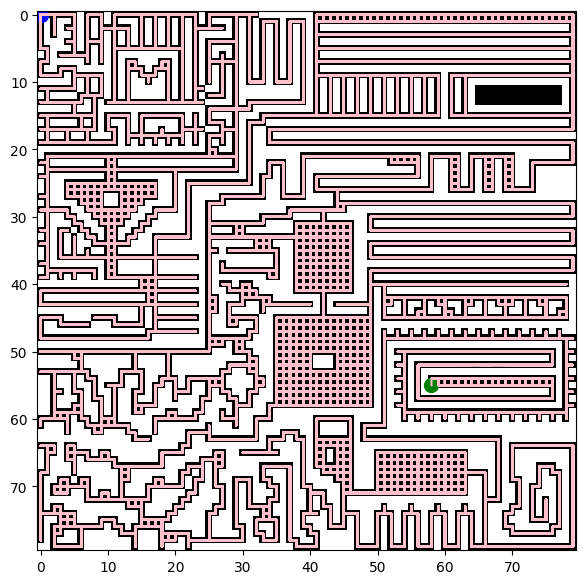

In [ ]:
# Please keep your parameters for the ACO easily changeable here
ants_per_gen = 1
no_generations = 1
q = 1600
evap = 0.1

maze_types = ["easy","medium","hard","insane","toy"]
maze_type = maze_types[2]
# Construct the optimization objects
maze = Maze.create_maze(f"./../data/{maze_type}_maze.txt")
spec = PathSpecification.read_coordinates(f"./../data/{maze_type}_coordinates.txt")
aco = AntColonyOptimization(maze, ants_per_gen, no_generations, q, evap)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec, print_progress_bar=True)
end_time = int(round(time.time() * 1000))

print(f"Time taken: {(end_time - start_time) / 1000.0} seconds")
print(f"Route size: {shortest_route.size()}")
shortest_route.write_to_file(f"./../data/{maze_type}_solution.txt")

Visualizer.visualize_individual_path(maze, shortest_route, spec)

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [6]:
# Class that represents the intelligent Ant (intelligAnt hehe)
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        # go to the next step until you find the end coordinate
        route = Route(self.start)

        # Coordinate already has __hash__ defined inside IntelligentAntColonyOptimization.find_shortest_route
        # this is done there to improve performance (you only define it 1 time per search instead of 1 time per ant)
        visited = {self.current_position}

        while self.current_position != self.end:
            surroundings = self.maze.get_surrounding_pheromone(self.current_position)
            # take a random direction, but weighted by pheromone quantity
            prob = [0,0,0,0]
            for i in range(4):
                new_pos = self.current_position.add_direction(Direction(i))

                # try to not go to coordinates that are already visited to prevent infinite loops
                # dont set to 0 because you could get stuck and then rand.choices raises an error
                # smart ants try to avoid backtracking and loops
                if new_pos in visited:
                    prob[i] = surroundings.get(Direction(i)) / 10000
                else:
                    prob[i] = surroundings.get(Direction(i))
            try:
                idx = self.rand.choices([0, 1, 2, 3], weights=prob, k=1)[0]
            except ValueError as ve:
                print(f"All weights are 0\n{prob}\n{surroundings}\n{self.current_position}\n{route}")
                raise ve
            
            next_step = Direction(idx)
            route.add(next_step)

            self.current_position = self.current_position.add_direction(next_step)
            visited.add(self.current_position)
        
        # remove any backtracking
        clean_steps = []
        pos = self.start
        visit_idxs = {}
        for step in route.get_route():
            if pos in visit_idxs:
                cutoff_idx = visit_idxs[pos]
                # if pos has been visited before then remove everything after the first visit to pos
                clean_steps = clean_steps[:cutoff_idx]
                # also clean up visit_idxs to prevent false positives
                visit_idxs = {k: v for k, v in visit_idxs.items() if v < cutoff_idx}
            visit_idxs[pos] = len(clean_steps)
            clean_steps.append(step)
            pos = pos.add_direction(step)
        
        res = Route(self.start)
        for step in clean_steps:
            res.add(step)
        return res

In [7]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class IntelligentAntColonyOptimization:
    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """

    def __init__(self, maze: Maze, ants_per_gen, generations, q, evaporation):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @param print_progress_bar: if it should print a progress bar
    @return the optimized route according to the ACO algorithm
    """

    def find_shortest_route(
        self, path_specification: PathSpecification, print_progress_bar: bool = False
    ):
        # add __hash__ to Coordinate to allow it to be added to sets
        # used by the intelligent ants to try avoiding backtracking
        def coordinate_hash(self):
            return hash((self.x, self.y))

        Coordinate.__hash__ = coordinate_hash

        self.maze.reset()
        # a dummy route that always returns infinity when you call size()
        # optimization because you dont have to check in the for loop if best_route is None
        best_route = type("", (Route,), {"size": lambda: float("inf")})
        for i in range(self.generations):
            routes = []
            for j in range(self.ants_per_gen):
                ant = IntelligentAnt(self.maze, path_specification)
                route = ant.find_route()
                routes.append(route)
                if route.shorter_than(best_route):
                    best_route = route

                # print a fancy progress bar
                # no influence on the actual algorithm but it allows the user to see how far they are
                if print_progress_bar:
                    iteration = i * self.ants_per_gen + j + 1
                    total = self.generations * self.ants_per_gen
                    percentage = f"{100 * (iteration / total):.2f}"

                    filledLength = int(50 * iteration // total)
                    bar = "█" * filledLength + "-" * (50 - filledLength)
                    print(f"\r|{bar}| {percentage}%", end="\r")
                    if iteration == total:
                        print()

            self.maze.add_pheromone_routes(routes, self.q)
            self.maze.evaporate(self.evaporation)

        # remove the change to Coordinate
        del Coordinate.__hash__

        return best_route

Additions:
- Ants are now encouraged to explore a lot more by ignoring most of the pheromone on places they have already visited before.
- When an ant has found a route, it will now clean up the route by removing unnecessary steps.

Let's see how much this improves the colonies' ability to find good paths!

Ready reading maze file ./../data/easy_maze.txt
Average normal ant colony time: 0.35212 seconds.
Average normal ant colony path length: 7636.6.


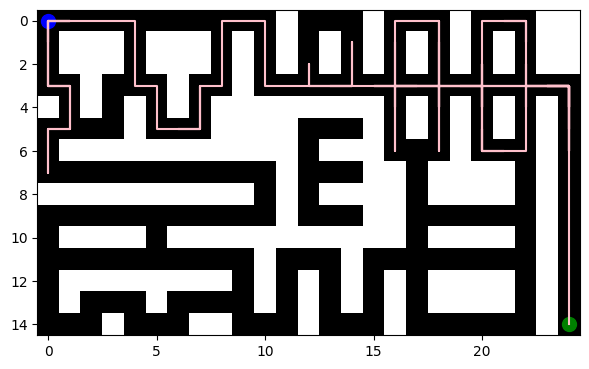

Average intelligent ant colony time: 0.07860 seconds.
Average intelligent ant colony path length: 72.66.


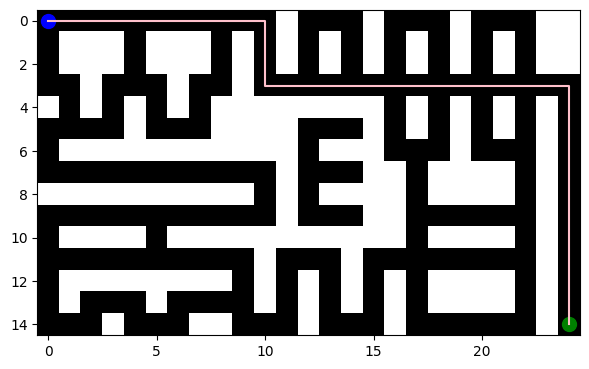

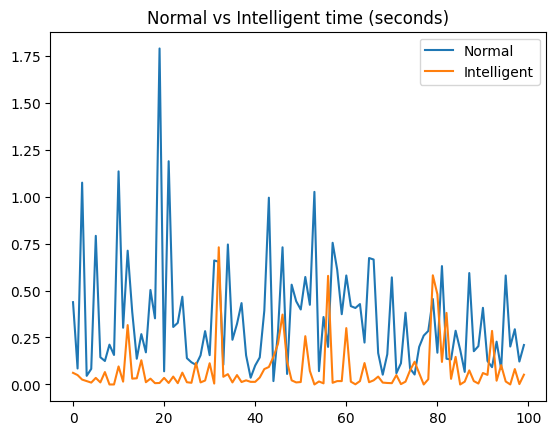

In [10]:
def run_colony(
        colony_class, maze, spec, ants_per_gen = 1, no_generations = 1, q = 1600, evap = 0.1, progress_bar = False
    ):

    aco = colony_class(maze, ants_per_gen, no_generations, q, evap)

    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec, print_progress_bar=progress_bar)
    end_time = int(round(time.time() * 1000))
    
    return shortest_route,(end_time - start_time)/1000

total_runs = 100
times = {"normal": np.zeros((total_runs,)), "smart": np.zeros((total_runs,))}
maze = Maze.create_maze(f"./../data/easy_maze.txt")
spec = PathSpecification.read_coordinates(f"./../data/easy_coordinates.txt")

normal_routes = []
intelligent_routes = []

for i in range(total_runs):
    # Normal ant colony on easy maze
    normal_route, normal_time = run_colony(AntColonyOptimization, maze, spec)
    normal_routes.append(normal_route)
    times["normal"][i] = normal_time
    maze.reset()
    
    # Intelligent ant colony on easy maze
    intelligent_route, intelligent_time = run_colony(IntelligentAntColonyOptimization, maze, spec)
    intelligent_routes.append(intelligent_route)
    times["smart"][i] = intelligent_time
    maze.reset()

normal_avg, intelligent_avg = 0,0
best_normal, best_intelligent = normal_routes[0], intelligent_routes[0]
for i in range(100):
    normal_avg += normal_routes[i].size()
    intelligent_avg += intelligent_routes[i].size()
    
    if normal_routes[i].shorter_than(best_normal):
        best_normal = normal_routes[i]
    if intelligent_routes[i].shorter_than(best_intelligent):
        best_intelligent = intelligent_routes[i]

normal_avg, intelligent_avg = normal_avg / total_runs, intelligent_avg / total_runs

print(f"Average normal ant colony time: {float(np.mean(times["normal"])):.5f} seconds.")
print(f"Average normal ant colony path length: {normal_avg}.")

Visualizer.visualize_individual_path(maze, best_normal, spec)

print(f"Average intelligent ant colony time: {float(np.mean(times["smart"])):.5f} seconds.")
print(f"Average intelligent ant colony path length: {intelligent_avg}.")

Visualizer.visualize_individual_path(maze, best_intelligent, spec)

plt.plot(times["normal"], label="Normal")
plt.plot(times["smart"], label="Intelligent")
plt.title("Normal vs Intelligent time (seconds)")
plt.legend()
plt.show()

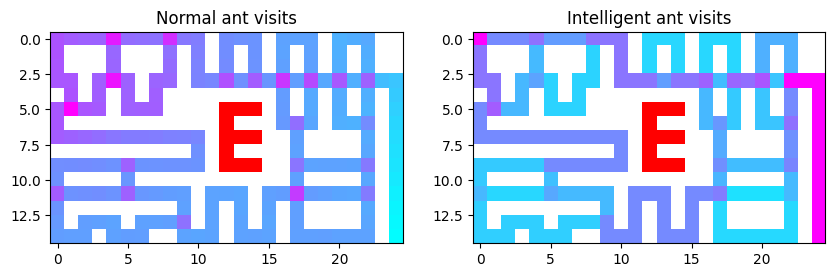

In [35]:
normal_visit_map = np.zeros((maze.get_length(), maze.get_width()))
intelligent_visit_map = np.zeros((maze.get_length(), maze.get_width()))
# the for loop doesnt count the starting cell when the ant starts, so add 100 for each ant
normal_visit_map[0,0] += 100
intelligent_visit_map[0, 0] += 100
mask = ~(np.array(maze.walls).T.astype(bool))
cmap = plt.cm.cool
cmap.set_bad("w")
cmap.set_under("r")

for route in normal_routes:
    curr_pos = route.get_start()
    x, y = curr_pos.get_x(), curr_pos.get_y()

    for direction in route.get_route():
        if direction.value == 0:  # East
            x += 1
        elif direction.value == 1:  # North
            y -= 1
        elif direction.value == 2:  # West
            x -= 1
        elif direction.value == 3:  # South
            y += 1

        normal_visit_map[y, x] += 1

for route in intelligent_routes:
    curr_pos = route.get_start()
    x, y = curr_pos.get_x(), curr_pos.get_y()

    for direction in route.get_route():
        if direction.value == 0:  # East
            x += 1
        elif direction.value == 1:  # North
            y -= 1
        elif direction.value == 2:  # West
            x -= 1
        elif direction.value == 3:  # South
            y += 1

        intelligent_visit_map[y, x] += 1


fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10, 10))

normal = np.ma.masked_where(mask, normal_visit_map)
ax1.imshow(normal, cmap=cmap, interpolation="nearest", vmin=0.01)
ax1.set_title("Normal ant visits")

intelligent = np.ma.masked_where(mask, intelligent_visit_map)
ax2.imshow(intelligent, cmap=cmap, interpolation="nearest", vmin=0.01)
ax2.set_title("Intelligent ant visits")

plt.show()

You can see that smart ants have a significantly shorter path than regular ants, and they find it a lot faster.  
I think this is mostly caused by discouraging backtracking. This forces the ants to find new cells instead of allowing them to go back and forth between $2$ neigboring cells. Letting the ants clean up the found routes before returning to the colony helps with reducing the final path length because it removes loops.  
The best route the normal ants found only visits $49$ extra tiles compared to the best path found be the intelligent ants, while the average path found by the normal ants is $\frac{7636.6}{72.66}\approx105.1$ times longer than the average path found by the intelligent ants.  

On the visit heatmaps, you can see that regular ants like wandering around more than the intelligent ants, because the regular ants have a smooth gradient while the intelligent ants have clearly defined edges.  
The regular ants also tend to visit intersections a lot more than the intelligent ants.  
You can also see that the finish is not visited very often in by the regular ants, which indicates that the regular ants spend a lot of time finding the finish.  
Finally, the intelligent ants like to go straight ahead when they only have one option.  
These changes are caused by discouraging backtracking:
1. The smooth gradient is a consequence of the ants revisiting the same cells a lot.
2. The intersections are passed so often because the ants go usually take every path from an intersection.
3. The finish is visited so little because the regular ants are usually in the maze.
4. The intelligent ants go straight ahead in corridors because they have two options: go the same way youre going, or go back but going back is heavily discouraged, so they continue in the same direction.


### 2.5 Parameter Optimization

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.6 The Final Route

#### Question 18

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19

In [0]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**